
## Level 1 — Task 1: Data Exploration and Preprocessing

### Objective

The objective of this task is to explore and preprocess the restaurant dataset.  
The analysis includes:

- Identifying the number of rows and columns
- Understanding the dataset structure
- Checking missing values
- Handling missing values
- Checking duplicate records
- Inspecting and converting data types
- Analysing the distribution of the target variable, `Aggregate rating`
- Identifying imbalance in the rating distribution

In [ ]:
# Import the required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Improve the appearance of charts
sns.set_theme(style="whitegrid")

# Display all columns when viewing the dataset
pd.set_option("display.max_columns", None)

In [ ]:
# Load the restaurant dataset

file_path = "/Dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Display the first five records

df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [ ]:
# Display the last five records

df.tail()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
9546,5915730,Naml۱ Gurme,208,��stanbul,"Kemanke�� Karamustafa Pa��a Mahallesi, R۱ht۱m ...",Karak�_y,"Karak�_y, ��stanbul",28.977392,41.022793,Turkish,80,Turkish Lira(TL),No,No,No,No,3,4.1,Green,Very Good,788
9547,5908749,Ceviz A��ac۱,208,��stanbul,"Ko��uyolu Mahallesi, Muhittin ��st�_nda�� Cadd...",Ko��uyolu,"Ko��uyolu, ��stanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",105,Turkish Lira(TL),No,No,No,No,3,4.2,Green,Very Good,1034
9548,5915807,Huqqa,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.034640,41.055817,"Italian, World Cuisine",170,Turkish Lira(TL),No,No,No,No,4,3.7,Yellow,Good,661
9549,5916112,A���k Kahve,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.036019,41.057979,Restaurant Cafe,120,Turkish Lira(TL),No,No,No,No,4,4.0,Green,Very Good,901
9550,5927402,Walter's Coffee Roastery,208,��stanbul,"Cafea��a Mahallesi, Bademalt۱ Sokak, No 21/B, ...",Moda,"Moda, ��stanbul",29.026016,40.984776,Cafe,55,Turkish Lira(TL),No,No,No,No,2,4.0,Green,Very Good,591


In [ ]:
# Display five randomly selected records

df.sample(5, random_state=42)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
4731,3918,Wah Ji Wah,1,New Delhi,"B-6/1, Double Story, Near Metro Pillar 371, Ra...",Kirti Nagar,"Kirti Nagar, New Delhi",77.128443,28.651778,North Indian,350,Indian Rupees(Rs.),No,No,No,No,1,2.1,Red,Poor,54
1468,18408054,19 Flavours Biryani,1,Gurgaon,"Global Foyer Mall, Sector 43, Golf Course Road...","Global Foyer Mall, Golf Course Road","Global Foyer Mall, Golf Course Road, Gurgaon",77.095432,28.460444,"Mughlai, Hyderabadi",700,Indian Rupees(Rs.),No,Yes,No,No,2,4.1,Green,Very Good,84
9037,309693,Andaaz E Paranthas,1,Noida,"306, 2nd Floor, Food Court, Spice World Mall, ...","Spice World Mall, Sector 25","Spice World Mall, Sector 25, Noida",77.340449,28.585474,"North Indian, Mughlai",550,Indian Rupees(Rs.),No,No,No,No,2,3.2,Orange,Average,36
7866,18157386,Tony's,1,New Delhi,"C-23, Single Storey, Vijay Nagar, New Delhi",Vijay Nagar,"Vijay Nagar, New Delhi",77.201128,28.692000,Fast Food,200,Indian Rupees(Rs.),No,Yes,No,No,1,4.4,Green,Very Good,163
5570,18396163,Yummy Adda,1,New Delhi,"1333, Near Batra Cinema, Mukherjee Nagar, New ...",Mukherjee Nagar,"Mukherjee Nagar, New Delhi",77.216130,28.712062,"North Indian, Mughlai",400,Indian Rupees(Rs.),No,No,No,No,1,3.5,Yellow,Good,14


In [ ]:
# Identify the number of rows and columns

rows, columns = df.shape

print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 9551
Number of columns: 21


### Observation

The dataset contains **9,551 restaurant records** and **21 columns**.  
Each row represents a restaurant, while the columns describe its location, cuisine, cost, services, ratings, and customer votes.

In [ ]:
# Display all column names

print("Columns in the dataset:\n")

for number, column in enumerate(df.columns, start=1):
    print(f"{number}. {column}")

Columns in the dataset:

1. Restaurant ID
2. Restaurant Name
3. Country Code
4. City
5. Address
6. Locality
7. Locality Verbose
8. Longitude
9. Latitude
10. Cuisines
11. Average Cost for two
12. Currency
13. Has Table booking
14. Has Online delivery
15. Is delivering now
16. Switch to order menu
17. Price range
18. Aggregate rating
19. Rating color
20. Rating text
21. Votes


In [ ]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [ ]:
# Create a summary of every column

column_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Non-Null Values": df.notnull().sum().values,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

column_summary

,Column,Data Type,Non-Null Values,Missing Values,Unique Values
0,Restaurant ID,int64,9551,0,9551
1,Restaurant Name,object,9551,0,7446
2,Country Code,int64,9551,0,15
3,City,object,9551,0,141
4,Address,object,9551,0,8918
5,Locality,object,9551,0,1208
6,Locality Verbose,object,9551,0,1265
7,Longitude,float64,9551,0,8120
8,Latitude,float64,9551,0,8677
9,Cuisines,object,9542,9,1825


In [ ]:
# Display the data type of each column

df.dtypes

,0
Restaurant ID,int64
Restaurant Name,object
Country Code,int64
City,object
Address,object
Locality,object
Locality Verbose,object
Longitude,float64
Latitude,float64
Cuisines,object


In [ ]:
# Count columns by data type

df.dtypes.value_counts()

,count
object,13
int64,5
float64,3


### Data-Type Observation

The dataset contains numerical and categorical variables.

- Numerical variables include ratings, votes, costs, geographical coordinates, and price ranges.
- Categorical variables include city, cuisines, currency, booking availability, delivery availability, rating text, and rating colour.
- The major columns already have suitable data types, so no compulsory numerical conversion is required at this stage.

In [ ]:
# Count missing values in each column

missing_values = df.isnull().sum()

print(missing_values)

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64


In [ ]:
# Create a missing-value summary

missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_summary = missing_summary[
    missing_summary["Missing Values"] > 0
].sort_values(by="Missing Values", ascending=False)

missing_summary

,Missing Values,Missing Percentage
Cuisines,9,0.09


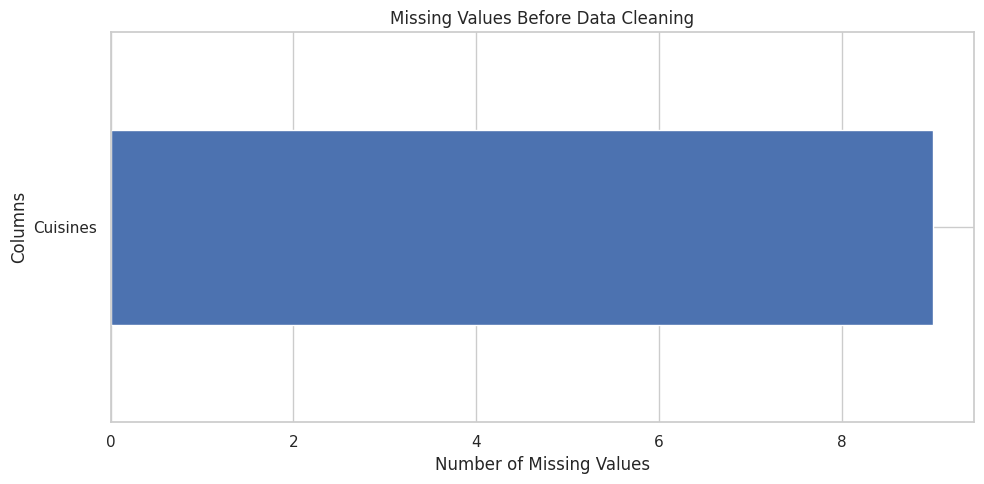

In [ ]:
# Visualise missing values before cleaning

plt.figure(figsize=(10, 5))

missing_values[missing_values > 0].sort_values().plot(
    kind="barh"
)

plt.title("Missing Values Before Data Cleaning")
plt.xlabel("Number of Missing Values")
plt.ylabel("Columns")
plt.tight_layout()
plt.show()

In [ ]:
# Replace missing cuisine values with 'Unknown'

df["Cuisines"] = df["Cuisines"].fillna("Unknown")

print("Missing cuisine values handled successfully.")

Missing cuisine values handled successfully.


In [ ]:
# Recheck missing values after cleaning

print("Total missing values after cleaning:", df.isnull().sum().sum())

Total missing values after cleaning: 0


### Missing-Value Treatment

The `Cuisines` column contained 9 missing values, representing approximately 0.09% of the dataset. These values were replaced with `"Unknown"`.

This approach preserves the restaurant records while clearly identifying entries for which cuisine information was unavailable. After treatment, no missing values remain in the dataset.

In [ ]:
# Check the number of completely duplicated rows

duplicate_rows = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 0


In [ ]:
# Check duplicated restaurant IDs

duplicate_ids = df["Restaurant ID"].duplicated().sum()

print("Number of duplicate Restaurant IDs:", duplicate_ids)

Number of duplicate Restaurant IDs: 0


In [ ]:
# Remove duplicate records if any are found

df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after duplicate removal:", df.shape)

Dataset shape after duplicate removal: (9551, 21)


In [ ]:
# Identify all text columns

text_columns = df.select_dtypes(include="object").columns

# Remove leading and trailing spaces

for column in text_columns:
    df[column] = df[column].str.strip()

print("Text columns cleaned successfully.")

Text columns cleaned successfully.


In [ ]:
# Convert suitable text columns to categorical data type

categorical_columns = [
    "Currency",
    "Has Table booking",
    "Has Online delivery",
    "Is delivering now",
    "Switch to order menu",
    "Rating color",
    "Rating text"
]

for column in categorical_columns:
    df[column] = df[column].astype("category")

print("Categorical columns converted successfully.")

Categorical columns converted successfully.


In [ ]:
# Display data types after conversion

df[categorical_columns].dtypes

,0
Currency,category
Has Table booking,category
Has Online delivery,category
Is delivering now,category
Switch to order menu,category
Rating color,category
Rating text,category


### Data-Type Conversion

The original numerical columns already had appropriate integer or floating-point data types.

Selected categorical columns were converted from `object` to `category`. This makes their categorical nature explicit and may reduce memory usage.

In [ ]:
# Examine the minimum and maximum aggregate ratings

print("Minimum rating:", df["Aggregate rating"].min())
print("Maximum rating:", df["Aggregate rating"].max())

Minimum rating: 0.0
Maximum rating: 4.9


In [ ]:
# Check latitude and longitude ranges

print("Latitude range:")
print(df["Latitude"].min(), "to", df["Latitude"].max())

print("\nLongitude range:")
print(df["Longitude"].min(), "to", df["Longitude"].max())

Latitude range:
-41.330428 to 55.97698

Longitude range:
-157.948486 to 174.8320893


In [ ]:
# Check invalid negative values

print(
    "Negative average-cost values:",
    (df["Average Cost for two"] < 0).sum()
)

print(
    "Negative vote values:",
    (df["Votes"] < 0).sum()
)

Negative average-cost values: 0
Negative vote values: 0


## Target Variable

The target variable is **Aggregate rating**.

It represents the overall rating received by a restaurant and will later be predicted using machine-learning regression models.

In [ ]:
# Display descriptive statistics for the target variable

df["Aggregate rating"].describe()

,Aggregate rating
count,9551.000000
mean,2.666370
std,1.516378
min,0.000000
25%,2.500000
50%,3.200000
75%,3.700000
max,4.900000


In [ ]:
# Count each aggregate-rating value

rating_distribution = (
    df["Aggregate rating"]
    .value_counts()
    .sort_index()
)

rating_distribution

,count
Aggregate rating,
0.0,2148
1.8,1
1.9,2
2.0,7
2.1,15
2.2,27
2.3,47
2.4,87
2.5,110


In [ ]:
# Calculate the percentage of each aggregate-rating value

rating_percentage = (
    df["Aggregate rating"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

rating_summary = pd.DataFrame({
    "Restaurant Count": rating_distribution,
    "Percentage": rating_percentage
})

rating_summary

,Restaurant Count,Percentage
Aggregate rating,,
0.0,2148,22.49
1.8,1,0.01
1.9,2,0.02
2.0,7,0.07
2.1,15,0.16
2.2,27,0.28
2.3,47,0.49
2.4,87,0.91
2.5,110,1.15


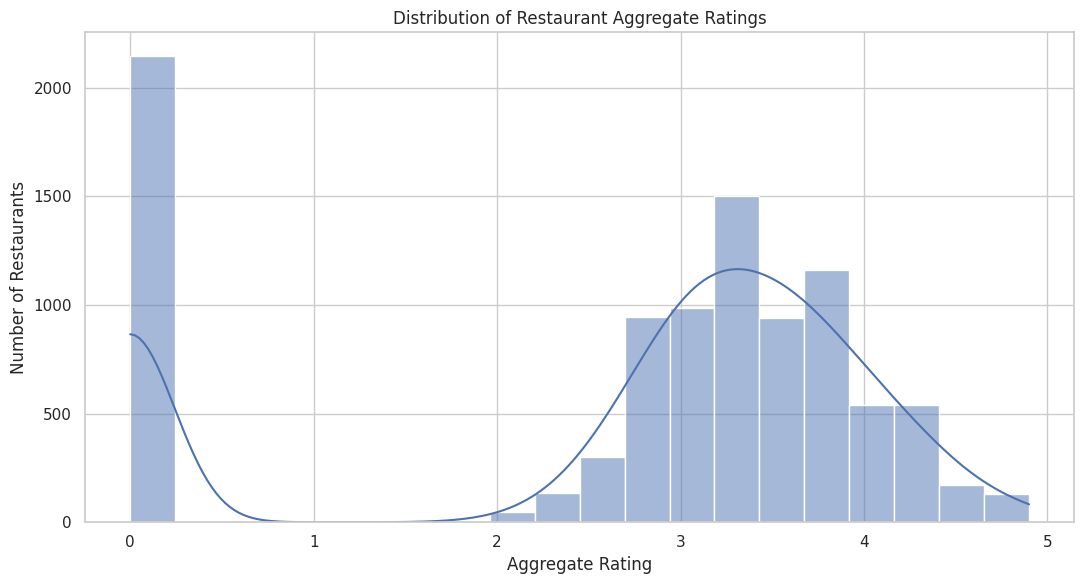

In [ ]:
# Plot the distribution of aggregate ratings

plt.figure(figsize=(11, 6))

sns.histplot(
    data=df,
    x="Aggregate rating",
    bins=20,
    kde=True
)

plt.title("Distribution of Restaurant Aggregate Ratings")
plt.xlabel("Aggregate Rating")
plt.ylabel("Number of Restaurants")
plt.tight_layout()
plt.show()

In [ ]:
# Count restaurants in every rating category

rating_text_counts = df["Rating text"].value_counts()

rating_text_counts

,count
Rating text,
Average,3737
Not rated,2148
Good,2100
Very Good,1079
Excellent,301
Poor,186


In [ ]:
# Calculate rating-category percentages

rating_text_percentage = (
    df["Rating text"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

rating_text_summary = pd.DataFrame({
    "Restaurant Count": rating_text_counts,
    "Percentage": rating_text_percentage
})

rating_text_summary

,Restaurant Count,Percentage
Rating text,,
Average,3737,39.13
Not rated,2148,22.49
Good,2100,21.99
Very Good,1079,11.30
Excellent,301,3.15
Poor,186,1.95


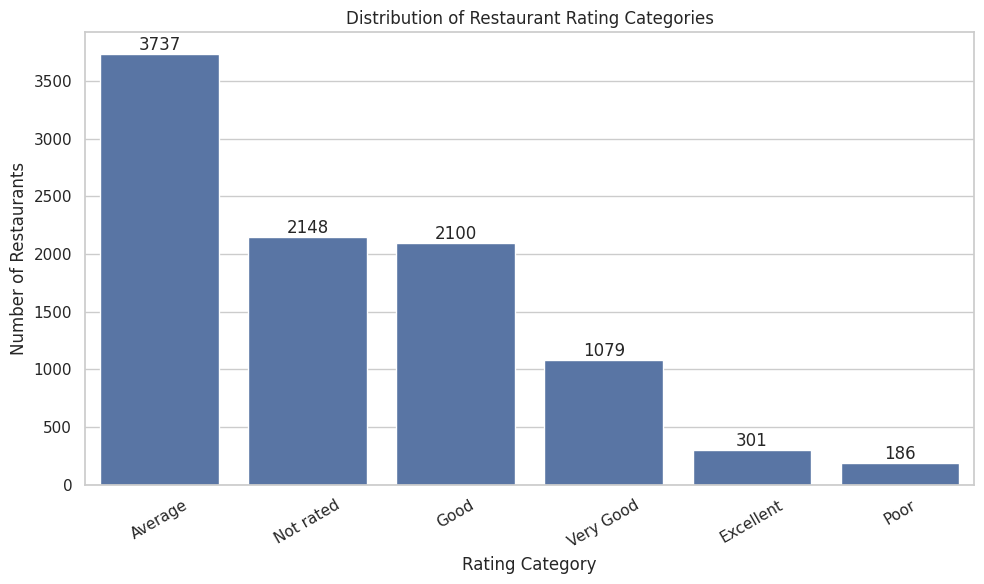

In [ ]:
# Plot rating-category distribution

plt.figure(figsize=(10, 6))

order = df["Rating text"].value_counts().index

ax = sns.countplot(
    data=df,
    x="Rating text",
    order=order
)

plt.title("Distribution of Restaurant Rating Categories")
plt.xlabel("Rating Category")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=30)

# Add count labels above the bars
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [ ]:
# Calculate the largest and smallest rating categories

largest_category = rating_text_counts.idxmax()
largest_count = rating_text_counts.max()

smallest_category = rating_text_counts.idxmin()
smallest_count = rating_text_counts.min()

imbalance_ratio = largest_count / smallest_count

print("Largest category:", largest_category)
print("Largest category count:", largest_count)

print("\nSmallest category:", smallest_category)
print("Smallest category count:", smallest_count)

print("\nImbalance ratio:", round(imbalance_ratio, 2))

Largest category: Average
Largest category count: 3737

Smallest category: Poor
Smallest category count: 186

Imbalance ratio: 20.09


### Target Distribution and Imbalance Observation

The rating distribution is imbalanced.

- `Average` is the largest category, containing 3,737 restaurants or about 39.13% of the dataset.
- `Poor` is the smallest category, containing only 186 restaurants or approximately 1.95%.
- `Excellent` ratings also form a relatively small category.
- A substantial 2,148 restaurants, or 22.49%, are marked as `Not rated`.

The largest category is approximately 20 times larger than the smallest category. Therefore, the rating categories are not evenly represented.

Because `Aggregate rating` is a continuous numerical target, the predictive task will use regression rather than classification. However, this uneven target distribution must still be considered during model evaluation.

In [ ]:
# Create a rated/unrated grouping

df["Rating Status"] = np.where(
    df["Aggregate rating"] == 0,
    "Not Rated",
    "Rated"
)

rating_status_counts = df["Rating Status"].value_counts()

rating_status_counts

,count
Rating Status,
Rated,7403
Not Rated,2148


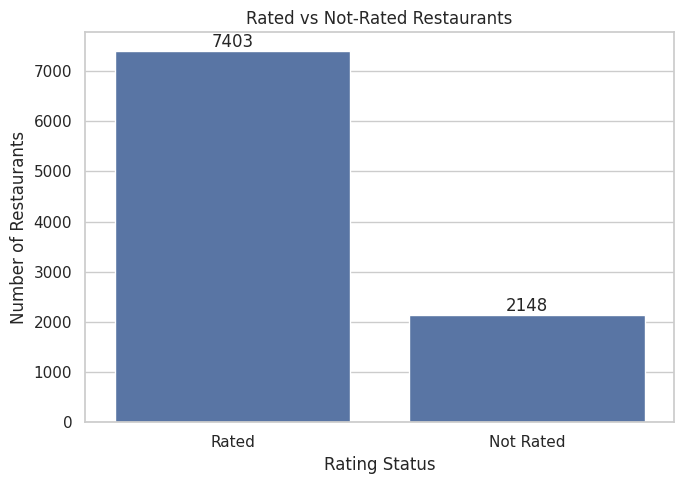

In [ ]:
# Visualise rated and unrated restaurants

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="Rating Status"
)

plt.title("Rated vs Not-Rated Restaurants")
plt.xlabel("Rating Status")
plt.ylabel("Number of Restaurants")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [ ]:
# Save the preprocessed dataset

output_path = "/content/Cleaned_Dataset.csv"

df.to_csv(output_path, index=False)

print("Cleaned dataset saved successfully.")
print("Saved as:", output_path)

Cleaned dataset saved successfully.
Saved as: /content/Cleaned_Dataset.csv


In [ ]:
# Final validation of the cleaned dataset

print("Final number of rows:", df.shape[0])
print("Final number of columns:", df.shape[1])
print("Total missing values:", df.isnull().sum().sum())
print("Total duplicate rows:", df.duplicated().sum())

Final number of rows: 9551
Final number of columns: 22
Total missing values: 0
Total duplicate rows: 0


## Key Findings

1. The original dataset contains **9,551 rows and 21 columns**.
2. The `Cuisines` column contained only **9 missing values**, approximately **0.09%** of the dataset.
3. Missing cuisine values were replaced with `"Unknown"` to preserve the restaurant records.
4. No completely duplicated records were found.
5. The numerical variables already had appropriate numerical data types.
6. Selected text-based variables were converted to categorical data types.
7. The target variable for future predictive modelling is `Aggregate rating`.
8. A total of **2,148 restaurants**, approximately **22.49%**, have an aggregate rating of `0.0` and are marked as `Not rated`.
9. The most common rating category is `Average`, representing approximately **39.13%** of restaurants.
10. The least common category is `Poor`, representing approximately **1.95%** of restaurants.
11. The distribution is imbalanced, with the largest category approximately 20 times larger than the smallest category.

## Conclusion

The restaurant dataset was successfully explored and preprocessed. It contains 9,551 restaurant records and 21 original attributes.

Only nine missing values were identified, all in the `Cuisines` column. These were replaced with `"Unknown"`, and no duplicate records were found. Text values were cleaned, selected categorical columns were converted to appropriate data types, and the cleaned dataset was saved for use in subsequent tasks.

The target variable, `Aggregate rating`, has an uneven distribution. Average-rated and unrated restaurants form a large portion of the dataset, while Poor and Excellent ratings are comparatively uncommon. This imbalance should be considered during future statistical analysis and predictive modelling.